In [1]:
!pip install biopython

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 28.9 MB/s eta 0:00:00


In [2]:
from Bio import SeqIO

In [3]:
filepath = 'HPV_cdhit.fa'
records = list(SeqIO.parse(filepath, 'fasta'))
print(f"Number of seqs: {len(records)}")

Number of seqs: 61082


In [4]:
print(records[0].id)
print(records[0].seq)

chr9:99841705-99842705
GGAGTTCAAGACCAGTGTAGGCAATATGGGAGTTCAAGACCTGCCTAGGCAATATAGGAGTTCAAGACCAGCCTAGGCAATATAGAGACACTGCCTCTACAAAAAATAGAAAAAATTAGATGGGCGTGGTGGTTCCTGCCTGTGGTTCCAGCTACTCAAGAGGCTGAGGTGGGAGGATCGCCTCAGCTGGGGAAGTCGAGGCTGTAGTGAGCCCTGATCACACCATTGCACTCCAGCCTGAGGAACAGAGCGAGACCCTGTCTCAAAAAAAAATTTTTTTTGAGGAAGGTATCCCCATTTTACAGAGTAGAAAGCTGAGGTTCATAAAAGCAAAATGATCCTACATTATTTCCCATATTAGGGGCCAGAACAAAATTGAGATTAAAGTAGCTGGACTCTCTGATTTTTTTTTTTTTTTTTTTAGTTATTTAATACTGCTTCTTGGGAAAACACAAAGAAAAAAAGACCCAATTAAATAAGCGTCTCATTTCCTCTCACCCAGGTAGCTCCACAGTAAGCACCTAGTTGCTTATTAGCTGTTTCTTCTCCAACCAGGTTAGGATATTACAGCAAACCTAAGCACTCTTCTGACTATTCTTTCATTGAAAAAATATTCAACAGTTATTTATTGAGGTGTAATTATGTGCCAGTCACTGTACTGTTGACAGAAACATAGGACCAATGAATACATACCTGGAGAGCTCCAGTGAGAGTAAAGCAAAATGCTTTTTAAAGATTTCATAGGCCAGACGCGGTGGCTCACGCCTGTAATCCCACCACTTCAGGAGGCCAAGGCAGGTGGATCACTTGAGGTCAGGAGTTTGAGACCAGCTTGGCCAACATGGTGAAACCCTGTCTCTACTAAAAATACAAAAGTTAGCCAGGCATGGTAGCACACACCTGTAGTTCCAGCTACTCGGGAGGCTGAGGCACGGAATCGCTTGAACCCAGGAGGTGGAGGTTTCAGTGAGCCAAGA

In [5]:
filepath_n = 'neg_HPV_ch2d.fa'
records_n = list(SeqIO.parse(filepath_n, 'fasta'))
print(f"Number of seqs: {len(records_n)}")

Number of seqs: 181207


In [ ]:
import matplotlib.pyplot as plt

## 610,820 negatives


In [ ]:
from Bio import SeqIO
import random

input_file = "neg_hbv_cd_hit_2d"
output_file = "negatives_sampled.fa"
sample_size = 61082

sequences = list(SeqIO.parse(input_file, "fasta"))

sampled = random.sample(sequences, sample_size)

SeqIO.write(sampled, output_file, "fasta")


61082

In [ ]:
from google.colab import files

files.download("negatives_sampled.fa")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [6]:
from Bio import SeqIO
import random

# Load FASTA records
pos_records = list(SeqIO.parse("HPV_cdhit.fa", "fasta"))
neg_records = list(SeqIO.parse("neg_HPV_ch2d.fa", "fasta"))

# Assign labels and update description
for record in pos_records:
    record.description += " label=1"
    record.id = record.id.split()[0]  # Clean ID if needed
    record.name = ""

for record in neg_records:
    record.description += " label=0"
    record.id = record.id.split()[0]
    record.name = ""

# Combine and shuffle
combined = pos_records + neg_records
random.shuffle(combined)

# Write to single labeled FASTA
SeqIO.write(combined, "labeled_717.fa", "fasta")

# Optional: download in Colab
from google.colab import files
files.download("labeled_717.fa")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# prompt: count sequences in combined_715

with open("labeled_717.fa", "r") as f:
  count = 0
  for line in f:
    if line.startswith(">"):
      count += 1
  print(f"Number of sequences in .fa: {count}")

Number of sequences in .fa: 242289


In [ ]:
from Bio import SeqIO

def parse_fasta_with_labels(file_path):
    sequences = []
    labels = []
    for record in SeqIO.parse(file_path, "fasta"):
        seq = str(record.seq).upper()
        header = record.description
        if "label=" in header:
            label = int(header.split("label=")[-1])
            sequences.append(seq)
            labels.append(label)
        else:
            raise ValueError(f"No label found in header: {header}")
    return sequences, labels

# Load sequences and labels
sequences_n, labels_n = parse_fasta_with_labels("final_combined.fa")


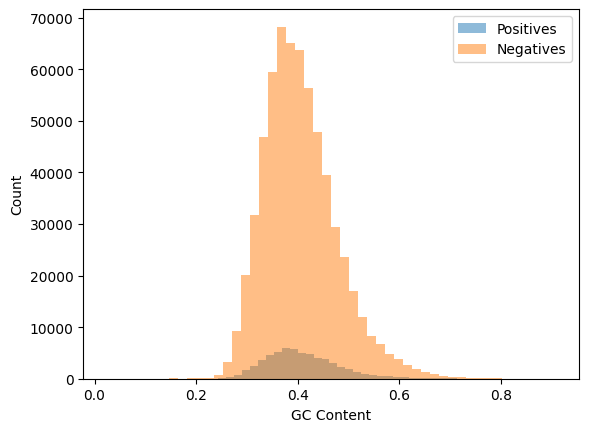

In [ ]:
def compute_gc(seq):
    gc = seq.count("G") + seq.count("C")
    return gc / len(seq)

gc_pos = [compute_gc(seq) for seq, label in zip(sequences_n, labels_n) if label == 1]
gc_neg = [compute_gc(seq) for seq, label in zip(sequences_n, labels_n) if label == 0]

plt.hist(gc_pos, bins=50, alpha=0.5, label='Positives')
plt.hist(gc_neg, bins=50, alpha=0.5, label='Negatives')
plt.xlabel('GC Content')
plt.ylabel('Count')
plt.legend()
plt.show()


In [ ]:
print("Number of sequences:", len(shuffled_records))
print("Number of labels:", len(shuffled_labels))

Number of sequences: 689689
Number of labels: 689689
